In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Load ---
df = pd.read_csv("fars_train.csv")
print(df.shape)

(45286, 39)


In [4]:
# --- 2. Define the binary target ---
# drunk_driver_involved -> 1, everything else (speeding_driver_involved, other) -> 0
df["y"] = (df["driver_factor"] == "drunk_driver_involved").astype(int)
print(df["y"].value_counts(normalize=True))

y
0    0.738043
1    0.261957
Name: proportion, dtype: float64


In [5]:
# --- 3. Define the two sensitive groups (keep separate, don't lose these) ---
# Urban vs rural
df["group_urban"] = (df["a_ru"] == "Urban").astype(int)   # 1 = urban, 0 = rural

# Young vs other driver, age < 30
df["group_young"] = (df["age"] < 30).astype(int)          # 1 = young, 0 = other

In [6]:
# --- 4. Drop rows where the sensitive attribute itself is missing ---
# We can't fairness-check a group we can't identify -- don't impute this one.
df = df.dropna(subset=["a_ru"]).reset_index(drop=True)
print(df.shape)  # should drop ~200 rows

(45086, 42)


In [7]:
# --- 5. Build the feature matrix ---
# Drop the id, the raw 3-class label, and the target -- keep group_urban/group_young
# IN the feature set for now (matches the paper's own approach: sensitive attributes
# are also model inputs). We'll pull them back out as separate arrays after encoding.
drop_cols = ["u_id", "driver_factor", "y"]
X = df.drop(columns=drop_cols)
y = df["y"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print(f"{len(cat_cols)} categorical, {len(num_cols)} numeric")

24 categorical, 15 numeric


In [8]:
# --- 6. Handle missing values ---
# Numeric -> median fill. Categorical -> explicit "Missing" category
# (safer than guessing, and missingness itself might carry signal).
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())
for c in cat_cols:
    X[c] = X[c].fillna("Missing")

print(X.isnull().sum().sum())  # should be 0 now

0


In [9]:
# --- 7. One-hot encode categorical columns ---
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print(X_encoded.shape)

(45086, 193)


In [10]:
# --- 8. Train/test split (80/20, stratified on the target) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=3, stratify=y
)

# Pull the group columns out as their own arrays for later (stage 2 needs these)
gu_train, gu_test = X_train["group_urban"], X_test["group_urban"]
gy_train, gy_test = X_train["group_young"], X_test["group_young"]

# Now drop them from the actual model inputs -- they're redundant with
# a_ru's one-hot columns and the raw 'age' column already in X.
X_train = X_train.drop(columns=["group_urban", "group_young"])
X_test = X_test.drop(columns=["group_urban", "group_young"])

print(X_train.shape, X_test.shape)

(36068, 191) (9018, 191)


In [11]:
# Remove the dropped group columns from num_cols so scaling doesn't look for them
num_cols = [c for c in num_cols if c not in ["group_urban", "group_young"]]

In [12]:
# --- 9. Scale numeric columns only (one-hot columns are already 0/1) ---
# Fit the scaler on TRAIN ONLY, then apply to test -- fitting on test would leak
# information about the test set's distribution into training.
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

input_dim = X_train_scaled.shape[1]


import numpy as np, random, tensorflow as tf
SEED = 42
tf.keras.utils.set_random_seed(SEED)   # seeds python, numpy and tensorflow together
# --- Switches: set True/False for whichever combination you want to test ---
USE_DROPOUT = True
USE_L1L2 = False

# Dropout(0.0) is a no-op -- turning USE_DROPOUT off just sets the rate to 0
dropout_rate = 0.2 if USE_DROPOUT else 0.0

# reg is either the L1/L2 penalty object, or None (= no penalty)
reg = regularizers.l1_l2(l1=1e-4, l2=1e-3) if USE_L1L2 else None

model = Sequential([
    Dense(8, activation="relu", input_shape=(input_dim,), kernel_regularizer=reg),
    Dropout(dropout_rate),
    Dense(16, activation="relu", kernel_regularizer=reg),
    Dropout(dropout_rate),
    Dense(32, activation="relu", kernel_regularizer=reg),
    Dropout(dropout_rate),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(dropout_rate),
    Dense(32, activation="relu", kernel_regularizer=reg),
    Dropout(dropout_rate),
    Dense(16, activation="relu", kernel_regularizer=reg),
    Dropout(dropout_rate),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,961 (27.19 KB)

 Trainable params: 6,961 (27.19 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- Train the model ---
# Passing X_test_scaled/y_test in as validation_data lets Keras report
# train vs. validation loss/accuracy after every epoch, without touching
# training in any way -- it's purely for monitoring.
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=300,
    batch_size=128,
    verbose=1,   # prints one line per epoch; set to 2 for less scrolling
)

Epoch 1/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7237 - loss: 0.5647 - val_accuracy: 0.7656 - val_loss: 0.4604
Epoch 2/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7606 - loss: 0.4738 - val_accuracy: 0.7680 - val_loss: 0.4564
Epoch 3/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7719 - loss: 0.4584 - val_accuracy: 0.7709 - val_loss: 0.4515
Epoch 4/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7767 - loss: 0.4508 - val_accuracy: 0.7763 - val_loss: 0.4485
Epoch 5/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7814 - loss: 0.4446 - val_accuracy: 0.7739 - val_loss: 0.4499
Epoch 6/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7845 - loss: 0.4420 - val_accuracy: 0.7788 - val_loss: 0.4458
Epoch 7/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7889 - loss: 0.4376 - val_accuracy: 0.7783 - val_loss: 0.4493
Epoch 8/300
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7853 - loss: 0.4364 - val_accu

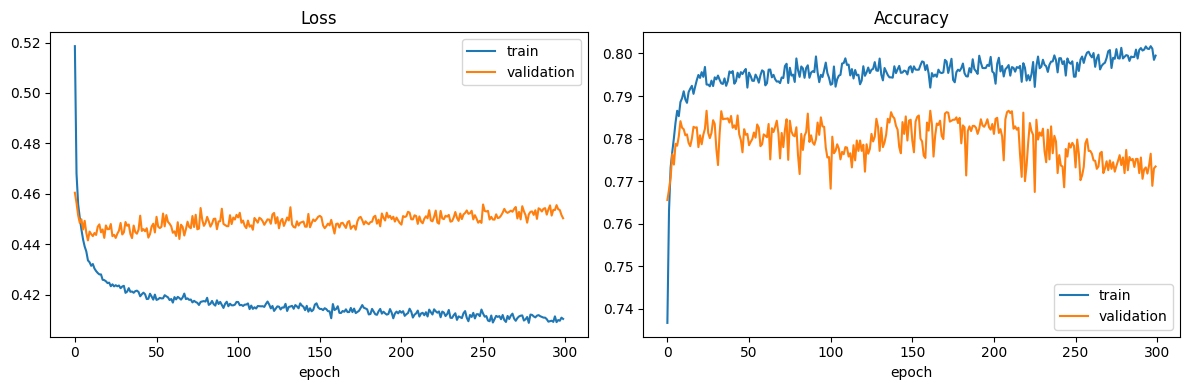

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
probs = model.predict(X_test_scaled).ravel()
# This is the "Default Threshold" -- everyone gets the same cutoff,
# 0.5, regardless of group. This is exactly the baseline the paper's
# threshold-modification method is meant to improve on.
preds = (probs >= 0.5).astype(int)



from sklearn.metrics import accuracy_score

# Sanity check -- should be close to the val_accuracy plateau you saw
# during training (~0.74-0.76), since this is the same test set.
overall_acc = accuracy_score(y_test, preds)
print(f"Overall accuracy (default threshold 0.5): {overall_acc:.4f}")

# gu_test, y_test, and X_test all came out of the SAME train_test_split
# call, so they share the same row order/index. That means a boolean
# mask built from gu_test can be used directly to slice y_test and preds
# without any extra alignment step.
urban_mask = (gu_test == 1)   # rows where the driver's crash was in an urban area
rural_mask = (gu_test == 0)   # rows where it was rural

urban_acc = accuracy_score(y_test[urban_mask], preds[urban_mask])
rural_acc = accuracy_score(y_test[rural_mask], preds[rural_mask])

print(f"Urban accuracy: {urban_acc:.4f}  (n={urban_mask.sum()})")
print(f"Rural accuracy: {rural_acc:.4f}  (n={rural_mask.sum()})")
print(f"Gap (urban - rural): {urban_acc - rural_acc:.4f}")

# Same logic, using the age-based group column instead.
young_mask = (gy_test == 1)   # driver age < 25
other_mask = (gy_test == 0)   # driver age >= 25

young_acc = accuracy_score(y_test[young_mask], preds[young_mask])
other_acc = accuracy_score(y_test[other_mask], preds[other_mask])

print(f"Young accuracy: {young_acc:.4f}  (n={young_mask.sum()})")
print(f"Other accuracy: {other_acc:.4f}  (n={other_mask.sum()})")
print(f"Gap (young - other): {young_acc - other_acc:.4f}")


# All the DT-baseline numbers together -- this is what the z-test
# in the next stage will check for statistical significance, and what
# the threshold-modification step will try to shrink.
print("\n--- Default Threshold (0.5) baseline ---")
print(f"Overall: {overall_acc:.4f}")
print(f"Urban:   {urban_acc:.4f}   Rural:  {rural_acc:.4f}   Gap: {urban_acc - rural_acc:.4f}")
print(f"Young:   {young_acc:.4f}   Other:  {other_acc:.4f}   Gap: {young_acc - other_acc:.4f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Overall accuracy (default threshold 0.5): 0.7735
Urban accuracy: 0.8093  (n=4687)
Rural accuracy: 0.7347  (n=4331)
Gap (urban - rural): 0.0746
Young accuracy: 0.7490  (n=3060)
Other accuracy: 0.7860  (n=5958)
Gap (young - other): -0.0370

--- Default Threshold (0.5) baseline ---
Overall: 0.7735
Urban:   0.8093   Rural:  0.7347   Gap: 0.0746
Young:   0.7490   Other:  0.7860   Gap: -0.0370


In [17]:
# ============================================================
#(= Algorithm 1, Line 1-2)
# Solve Subproblem (5)-(7) for each group: find that group's own
# best-possible accuracy (a_g) and the threshold that achieves it,
# ignoring the other group entirely.
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score

z_critical = 2.576  # 99% confidence, two-tailed

def find_optimal_threshold(probs_group, y_group):
    """
    Exhaustively searches for the threshold that maximizes accuracy
    WITHIN a single group.

    Why this works exactly (not approximately): accuracy only changes
    value at points where the threshold crosses one of this group's
    own observed probabilities -- so those probabilities are the only
    candidate thresholds we ever need to check.

    Returns: (best_threshold, best_accuracy)
    """
    # Candidate thresholds = every unique probability this group has.
    # No need to check anything else -- see the walkthrough we did earlier.
    candidates = np.unique(probs_group)

    best_acc = -1
    best_thresh = None

    for tau in candidates:
        preds = (probs_group >= tau).astype(int)
        acc = accuracy_score(y_group, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = tau

    return best_thresh, best_acc


# --- Apply to the urban/rural grouping ---
theta_urban, a_urban = find_optimal_threshold(probs[urban_mask], y_test[urban_mask])
theta_rural, a_rural = find_optimal_threshold(probs[rural_mask], y_test[rural_mask])

print("--- Urban/Rural: Subproblem (5)-(7) results ---")
print(f"Urban: optimal threshold = {theta_urban:.4f}, optimal accuracy a_urban = {a_urban:.4f}")
print(f"Rural: optimal threshold = {theta_rural:.4f}, optimal accuracy a_rural = {a_rural:.4f}")

# --- Apply to the young/other grouping ---
theta_young, a_young = find_optimal_threshold(probs[young_mask], y_test[young_mask])
theta_other, a_other = find_optimal_threshold(probs[other_mask], y_test[other_mask])

print("\n--- Young/Other: Subproblem (5)-(7) results ---")
print(f"Young: optimal threshold = {theta_young:.4f}, optimal accuracy a_young = {a_young:.4f}")
print(f"Other: optimal threshold = {theta_other:.4f}, optimal accuracy a_other = {a_other:.4f}")

# --- Algorithm 1, Line 2: identify the disadvantaged group in each pair ---
# Whichever group has the SMALLER a_g here is the disadvantaged group --
# its threshold from this step is already final (Lemma 1 / Proposition 2).
if a_urban <= a_rural:
    print(f"\nUrban/Rural: disadvantaged = urban (a={a_urban:.4f}), advantaged = rural (a={a_rural:.4f})")
else:
    print(f"\nUrban/Rural: disadvantaged = rural (a={a_rural:.4f}), advantaged = urban (a={a_urban:.4f})")

if a_young <= a_other:
    print(f"Young/Other: disadvantaged = young (a={a_young:.4f}), advantaged = other (a={a_other:.4f})")
else:
    print(f"Young/Other: disadvantaged = other (a={a_other:.4f}), advantaged = young (a={a_young:.4f})")


if a_urban <= a_rural:
    disadv_ur, adv_ur = "urban", "rural"
else:
    disadv_ur, adv_ur = "rural", "urban"

if a_young <= a_other:
    disadv_yo, adv_yo = "young", "other"
else:
    disadv_yo, adv_yo = "other", "young"

N_urban = int(urban_mask.sum())
N_rural = int(rural_mask.sum())
N_young = int(young_mask.sum())
N_other = int(other_mask.sum())

group_data = {
    "urban": (theta_urban, a_urban, N_urban),
    "rural": (theta_rural, a_rural, N_rural),
    "young": (theta_young, a_young, N_young),
    "other": (theta_other, a_other, N_other),
}
group_mask = {
    "urban": urban_mask, "rural": rural_mask,
    "young": young_mask, "other": other_mask,
}

--- Urban/Rural: Subproblem (5)-(7) results ---
Urban: optimal threshold = 0.5389, optimal accuracy a_urban = 0.8137
Rural: optimal threshold = 0.5479, optimal accuracy a_rural = 0.7483

--- Young/Other: Subproblem (5)-(7) results ---
Young: optimal threshold = 0.6023, optimal accuracy a_young = 0.7690
Other: optimal threshold = 0.5390, optimal accuracy a_other = 0.7892

Urban/Rural: disadvantaged = rural (a=0.7483), advantaged = urban (a=0.8137)
Young/Other: disadvantaged = young (a=0.7690), advantaged = other (a=0.7892)


In [18]:
# ============================================================
# (Algorithm 1, Line 3 -- Proposition 3, Eq. 8)
# Solve for the advantaged group's target accuracy a*_g-bar,
# given the disadvantaged group's fixed accuracy from Step 1.
# ============================================================

import math

def solve_target_accuracy(a_disadv, N_disadv, a_bar_adv, N_adv, z_alpha=z_critical):
    """
    Implements Eq. (8) from the paper.

    a_disadv   : a_g       -- disadvantaged group's fixed accuracy (already optimal)
    N_disadv   : N_g       -- disadvantaged group's sample size
    a_bar_adv  : a_bar_g   -- advantaged group's OWN ceiling accuracy (from Step 1)
    N_adv      : N_g-bar   -- advantaged group's sample size
    z_alpha    : critical z-value (1.96 for 95% confidence, matching our z-test)

    Returns the advantaged group's TARGET accuracy a*_g-bar, and which
    case of Eq. (8) was used (for transparency / sanity-checking).
    """
    a_g = a_disadv
    N_g = N_disadv
    a_bar_g = a_bar_adv
    N_bar_g = N_adv

    # D, A, B, C exactly as defined under Eq. (8)
    D = (z_alpha ** 2) / ((N_g + N_bar_g) * N_g * N_bar_g)
    A = 1 + (N_bar_g ** 2) * D
    B = (2 * N_g * N_bar_g * a_g * D
         - N_g * N_bar_g * D
         - (N_bar_g ** 2) * D
         - 2 * a_g)
    C = (a_g ** 2) - (N_g**2 * a_g + N_g * N_bar_g * a_g - N_g**2 * a_g**2) * D

    discriminant = B**2 - 4 * A * C

    # Helper: evaluate f(a) = A*a^2 + B*a + C, used to pick the right case
    def f(a):
        return A * a**2 + B * a + C

    if discriminant > 0:
        root_plus = (-B + math.sqrt(discriminant)) / (2 * A)

        if f(a_g) < 0 and f(a_bar_g) >= 0:
            # Case 1: the advantaged group's ceiling WOULD violate fairness --
            # target sits strictly below the ceiling, at the exact z_alpha boundary.
            return root_plus, "Case 1 (reduced below ceiling)"
        elif f(a_g) < 0 and f(a_bar_g) < 0:
            # Case 2: even the ceiling accuracy already satisfies fairness --
            # no reduction needed.
            return a_bar_g, "Case 2 (ceiling already fair)"

    if discriminant == 0:
        root = -B / (2 * A)
        if a_g <= root <= a_bar_g:
            # Case 3: boundary/degenerate case.
            return root, "Case 3 (boundary)"

    # Case 4: no feasible solution.
    return None, "Case 4 (infeasible)"


# --- Urban/Rural: roles determined dynamically in Step 1 ---
theta_disadv_ur, a_disadv_ur, N_disadv_ur = group_data[disadv_ur]
theta_adv_ur, a_adv_ur, N_adv_ur = group_data[adv_ur]

target_ur, case_ur = solve_target_accuracy(
    a_disadv=a_disadv_ur, N_disadv=N_disadv_ur,
    a_bar_adv=a_adv_ur, N_adv=N_adv_ur,
)
print(f"Urban/Rural -> target accuracy for {adv_ur} (advantaged): {target_ur:.4f}  [{case_ur}]")
print(f"{disadv_ur.capitalize()} (disadvantaged) stays fixed at: {a_disadv_ur:.4f}")

# --- Young/Other: roles determined dynamically in Step 1 ---
theta_disadv_yo, a_disadv_yo, N_disadv_yo = group_data[disadv_yo]
theta_adv_yo, a_adv_yo, N_adv_yo = group_data[adv_yo]

target_yo, case_yo = solve_target_accuracy(
    a_disadv=a_disadv_yo, N_disadv=N_disadv_yo,
    a_bar_adv=a_adv_yo, N_adv=N_adv_yo,
)
print(f"\nYoung/Other -> target accuracy for {adv_yo} (advantaged): {target_yo:.4f}  [{case_yo}]")
print(f"{disadv_yo.capitalize()} (disadvantaged) stays fixed at: {a_disadv_yo:.4f}")

Urban/Rural -> target accuracy for urban (advantaged): 0.7715  [Case 1 (reduced below ceiling)]
Rural (disadvantaged) stays fixed at: 0.7483

Young/Other -> target accuracy for other (advantaged): 0.7892  [Case 2 (ceiling already fair)]
Young (disadvantaged) stays fixed at: 0.7690


In [19]:
# ============================================================
# (Algorithm 1, Line 4 -- threshold identification subproblem)
# Only needed for urban, since it's the one group whose target
# accuracy  differs from its own ceiling accuracy.
# Rural, young, and other already have their final thresholds from
# earlier steps -- rural/young are disadvantaged (fixed at their own
# optimum), and other landed in Case 2 (ceiling already satisfies
# fairness, so its Step 1 threshold is already the final one).
# ============================================================

import numpy as np

#def find_threshold_for_target_accuracy(probs_group, y_group, target_acc):
#    """
#    Searches candidate thresholds (the group's own observed probabilities,
#    same reasoning as Step 1) and returns whichever one produces an
#    accuracy CLOSEST to the target accuracy -- since the exact target
#    value from Eq. (8) may not be exactly achievable on discrete data.

#    Returns: (best_threshold, achieved_accuracy, difference_from_target)
#    """
#    candidates = np.unique(probs_group)

#    best_thresh = None
#    best_acc = None
#    best_diff = np.inf

#    for tau in candidates:
#        preds = (probs_group >= tau).astype(int)
#        acc = (preds == y_group).mean()
#        diff = abs(acc - target_acc)
#        if diff < best_diff:
#            best_diff = diff
#            best_acc = acc
#         best_thresh = tau
#
#    return best_thresh, best_acc, best_diff


def find_constrained_threshold(probs_group, y_group, a_fixed, N_fixed, z_alpha=z_critical):
    """
    Search every achievable threshold and return the one that maximizes
    this group's accuracy while keeping |z| <= z_alpha against the
    fixed-accuracy group. Enforces Problem (1)-(4)'s constraint directly
    on the real, achievable accuracy values, instead of matching the
    continuous Eq.(8) target accuracy (which may not be exactly
    achievable on finite data).
    """
    thresholds = np.unique(probs_group)
    N_group = len(y_group)
    best_theta, best_acc, best_z = None, -np.inf, None
    fallback_theta, fallback_acc, fallback_z, fallback_absz = None, None, None, np.inf
    for theta in thresholds:
        preds = (probs_group >= theta).astype(int)
        acc = accuracy_score(y_group, preds)
        p_pool = (acc * N_group + a_fixed * N_fixed) / (N_group + N_fixed)
        se = np.sqrt(p_pool * (1 - p_pool) * (1 / N_group + 1 / N_fixed))
        z = (acc - a_fixed) / se if se > 0 else 0.0
        if abs(z) < fallback_absz:
            fallback_theta, fallback_acc, fallback_z, fallback_absz = theta, acc, z, abs(z)
        if abs(z) <= z_alpha and acc > best_acc:
            best_theta, best_acc, best_z = theta, acc, z
    if best_theta is not None:
        return best_theta, best_acc, best_z
    return fallback_theta, fallback_acc, fallback_z  # constraint not exactly achievable; nearest reported

def apply_fair_threshold(adv_name, theta_adv_opt, a_adv_opt, target_acc, probs_adv, y_adv, case, a_disadv, N_disadv, z_alpha=z_critical):
    if abs(target_acc - a_adv_opt) < 1e-9:
        print(f"{adv_name}: [{case}] target accuracy matches current optimum. No threshold change needed.")
        return theta_adv_opt, a_adv_opt, 0.0
    else:
        theta_fair, achieved_acc, z_fair = find_constrained_threshold(probs_adv, y_adv, a_fixed=a_disadv, N_fixed=N_disadv, z_alpha=z_alpha)
        diff = achieved_acc - target_acc
        status = "constraint satisfied" if abs(z_fair) <= z_alpha else "constraint NOT achievable exactly on this data"
        print(f"{adv_name}: [{case}] theta_fair={theta_fair:.4f}, achieved={achieved_acc:.4f}, target={target_acc:.4f}, diff={diff:+.4f}, z={z_fair:.4f}  [{status}]")
        return theta_fair, achieved_acc, diff

theta_adv_ur_fair, acc_adv_ur_fair, diff_adv_ur = apply_fair_threshold(
    adv_ur, theta_adv_ur, a_adv_ur, target_ur,
    probs[group_mask[adv_ur]], y_test[group_mask[adv_ur]], case_ur,
    a_disadv=a_disadv_ur, N_disadv=N_disadv_ur
)
theta_adv_yo_fair, acc_adv_yo_fair, diff_adv_yo = apply_fair_threshold(
    adv_yo, theta_adv_yo, a_adv_yo, target_yo,
    probs[group_mask[adv_yo]], y_test[group_mask[adv_yo]], case_yo,
    a_disadv=a_disadv_yo, N_disadv=N_disadv_yo
)

# --- Final thresholds for all four groups (Algorithm 1, output) ---
final_theta = {
    disadv_ur: group_data[disadv_ur][0],
    adv_ur:    theta_adv_ur_fair,
    disadv_yo: group_data[disadv_yo][0],
    adv_yo:    theta_adv_yo_fair,
}

print("\n--- Final Fair Group Thresholds (FGT) ---")
for name in ["urban", "rural", "young", "other"]:
    role = "advantaged" if name in (adv_ur, adv_yo) else "disadvantaged"
    print(f"{name.capitalize()} ({role}): theta = {final_theta[name]:.4f}")

urban: [Case 1 (reduced below ceiling)] theta_fair=0.2234, achieved=0.7715, target=0.7715, diff=-0.0000, z=2.5753  [constraint satisfied]
other: [Case 2 (ceiling already fair)] target accuracy matches current optimum. No threshold change needed.

--- Final Fair Group Thresholds (FGT) ---
Urban (advantaged): theta = 0.2234
Rural (disadvantaged): theta = 0.5479
Young (disadvantaged): theta = 0.6023
Other (advantaged): theta = 0.5390


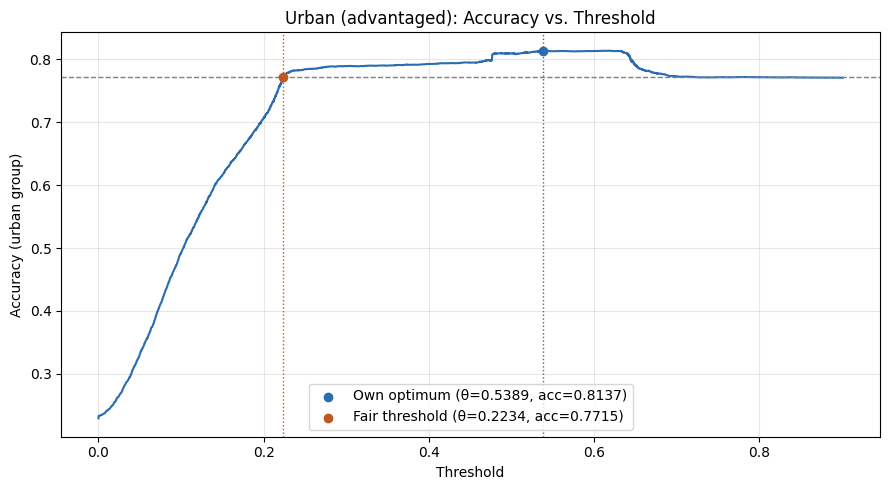

In [20]:
# ============================================================
# Accuracy vs Threshold curve for the URBAN group -- this lets us
# actually SEE the shape of the curve we've been reasoning about:
# the peak at (a_urban's own optimum), and why the
# target accuracy ends up being hit again near
# instead of just below the peak.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def accuracy_curve(probs_group, y_group):
    """Returns sorted (threshold, accuracy) pairs across the FULL
    range of candidate thresholds for a group."""
    candidates = np.unique(probs_group)
    accs = []
    for tau in candidates:
        preds = (probs_group >= tau).astype(int)
        accs.append((preds == y_group).mean())
    return candidates, np.array(accs)


adv_probs_ur = probs[group_mask[adv_ur]]
adv_y_ur = y_test[group_mask[adv_ur]]
thresholds_adv_ur, accs_adv_ur = accuracy_curve(adv_probs_ur, adv_y_ur)
theta_adv_ur_opt, a_adv_ur_opt, _ = group_data[adv_ur]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_adv_ur, accs_adv_ur, linewidth=1.5, color="#2b6cb0")

ax.axhline(target_ur, color="gray", linestyle="--", linewidth=1)
ax.axvline(theta_adv_ur_opt, color="#2b6cb0", linestyle=":", linewidth=1)
ax.axvline(theta_adv_ur_fair, color="#c05621", linestyle=":", linewidth=1)

ax.scatter([theta_adv_ur_opt], [a_adv_ur_opt], color="#2b6cb0", zorder=5,
           label=f"Own optimum (θ={theta_adv_ur_opt:.4f}, acc={a_adv_ur_opt:.4f})")
ax.scatter([theta_adv_ur_fair], [acc_adv_ur_fair], color="#c05621", zorder=5,
           label=f"Fair threshold (θ={theta_adv_ur_fair:.4f}, acc={acc_adv_ur_fair:.4f})")

ax.set_xlabel("Threshold")
ax.set_ylabel(f"Accuracy ({adv_ur} group)")
ax.set_title(f"{adv_ur.capitalize()} (advantaged): Accuracy vs. Threshold")
ax.legend(loc="lower center")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

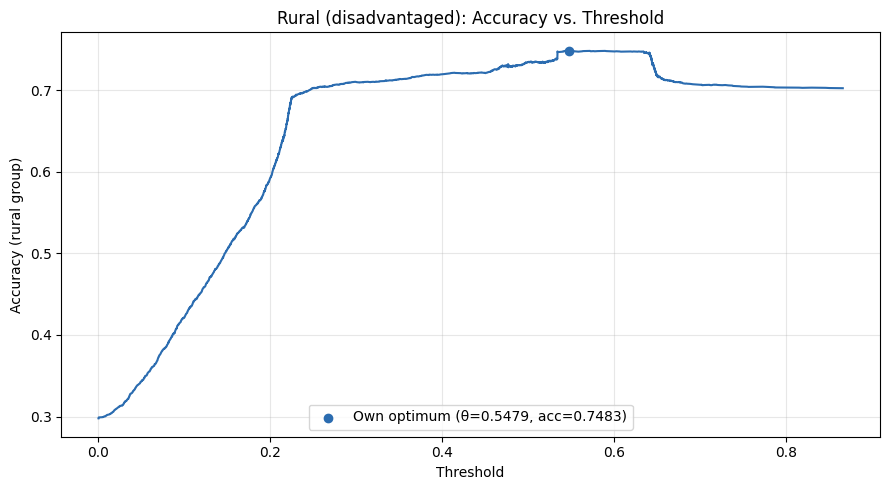

In [21]:
# ============================================================
# Accuracy vs Threshold curve for the RURAL group.
# Rural is the disadvantaged group, so it only has ONE relevant
# point marked -- its own optimum from Step 1 -- since its
# threshold was never adjusted (Lemma 1 / Proposition 2: the
# disadvantaged group stays at its own best accuracy).
# ============================================================

disadv_probs_ur = probs[group_mask[disadv_ur]]
disadv_y_ur = y_test[group_mask[disadv_ur]]
thresholds_disadv_ur, accs_disadv_ur = accuracy_curve(disadv_probs_ur, disadv_y_ur)
theta_disadv_ur_opt, a_disadv_ur_opt, _ = group_data[disadv_ur]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_disadv_ur, accs_disadv_ur, linewidth=1.5, color="#2b6cb0")

ax.scatter([theta_disadv_ur_opt], [a_disadv_ur_opt], color="#2b6cb0", zorder=5,
           label=f"Own optimum (θ={theta_disadv_ur_opt:.4f}, acc={a_disadv_ur_opt:.4f})")

ax.set_xlabel("Threshold")
ax.set_ylabel(f"Accuracy ({disadv_ur} group)")
ax.set_title(f"{disadv_ur.capitalize()} (disadvantaged): Accuracy vs. Threshold")
ax.legend(loc="lower center")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# (Algorithm 1, Lines 5-6)
# Apply the Fair Group Thresholds, recompute accuracies and the
# z-test, and build the final DT / OT / FGT comparison table.
#
# Note: Urban/Rural and Young/Other are two SEPARATE, independent
# fairness experiments (each is its own 2-group Problem (1)-(4)),
# so each gets its own full set of predictions and its own results
# -- they are not merged into one combined prediction array.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

def two_proportion_z(acc1, n1, acc2, n2):
    """Same two-proportion z-test formula used throughout Stage 6-7."""
    x1 = acc1 * n1
    x2 = acc2 * n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    return (acc1 - acc2) / se


# --- Urban/Rural: apply FGT ---
preds_fgt_ur = np.zeros(len(y_test), dtype=int)
preds_fgt_ur[urban_mask] = (probs[urban_mask] >= final_theta["urban"]).astype(int)
preds_fgt_ur[rural_mask] = (probs[rural_mask] >= final_theta["rural"]).astype(int)

acc_urban_fgt = accuracy_score(y_test[urban_mask], preds_fgt_ur[urban_mask])
acc_rural_fgt = accuracy_score(y_test[rural_mask], preds_fgt_ur[rural_mask])
overall_ur_fgt = (acc_urban_fgt * N_urban + acc_rural_fgt * N_rural) / (N_urban + N_rural)
z_ur_fgt = two_proportion_z(acc_urban_fgt, N_urban, acc_rural_fgt, N_rural)

print("--- Urban/Rural: Fair Group Threshold (FGT) results ---")
print(f"Urban accuracy: {acc_urban_fgt:.4f}   Rural accuracy: {acc_rural_fgt:.4f}")
print(f"Overall accuracy: {overall_ur_fgt:.4f}")

status_ur = "constraint satisfied" if abs(z_ur_fgt) <= z_critical else "constraint VIOLATED"
print(f"z-value: {z_ur_fgt:.4f}  (|z| <= {z_critical} -> {status_ur})")

# --- Young/Other: apply FGT ---
preds_fgt_yo = np.zeros(len(y_test), dtype=int)
preds_fgt_yo[young_mask] = (probs[young_mask] >= final_theta["young"]).astype(int)
preds_fgt_yo[other_mask] = (probs[other_mask] >= final_theta["other"]).astype(int)

acc_young_fgt = accuracy_score(y_test[young_mask], preds_fgt_yo[young_mask])
acc_other_fgt = accuracy_score(y_test[other_mask], preds_fgt_yo[other_mask])
overall_yo_fgt = (acc_young_fgt * N_young + acc_other_fgt * N_other) / (N_young + N_other)
z_yo_fgt = two_proportion_z(acc_young_fgt, N_young, acc_other_fgt, N_other)

print("\n--- Young/Other: Fair Group Threshold (FGT) results ---")
print(f"Young accuracy: {acc_young_fgt:.4f}   Other accuracy: {acc_other_fgt:.4f}")
print(f"Overall accuracy: {overall_yo_fgt:.4f}")

status_yo = "constraint satisfied" if abs(z_yo_fgt) <= z_critical else "constraint VIOLATED"
print(f"z-value: {z_yo_fgt:.4f}  (|z| <= {z_critical} -> {status_yo})")


# ============================================================
# Final comparison table: Default Threshold vs Optimal Threshold
# vs Fair Group Threshold, for both pairings.
# ============================================================
overall_ot_ur = (a_urban * N_urban + a_rural * N_rural) / (N_urban + N_rural)
z_ot_ur = two_proportion_z(a_urban, N_urban, a_rural, N_rural)

overall_ot_yo = (a_young * N_young + a_other * N_other) / (N_young + N_other)
z_ot_yo = two_proportion_z(a_young, N_young, a_other, N_other)

z_dt_ur = two_proportion_z(urban_acc, N_urban, rural_acc, N_rural)
z_dt_yo = two_proportion_z(young_acc, N_young, other_acc, N_other)

summary = pd.DataFrame([
    ["Urban/Rural", "Default Threshold (0.5)", urban_acc, rural_acc, overall_acc, z_dt_ur],
    ["Urban/Rural", "Optimal Threshold (per-group)", a_urban, a_rural, overall_ot_ur, z_ot_ur],
    ["Urban/Rural", "Fair Group Threshold", acc_urban_fgt, acc_rural_fgt, overall_ur_fgt, z_ur_fgt],
    ["Young/Other", "Default Threshold (0.5)", young_acc, other_acc, overall_acc, z_dt_yo],
    ["Young/Other", "Optimal Threshold (per-group)", a_young, a_other, overall_ot_yo, z_ot_yo],
    ["Young/Other", "Fair Group Threshold", acc_young_fgt, acc_other_fgt, overall_yo_fgt, z_yo_fgt],
], columns=["Grouping", "Method", "Group1 Acc", "Group2 Acc", "Overall Acc", "z-value"])

print("\n--- Final Comparison Table ---")
print(summary.to_string(index=False))

--- Urban/Rural: Fair Group Threshold (FGT) results ---
Urban accuracy: 0.7715   Rural accuracy: 0.7483
Overall accuracy: 0.7604
z-value: 2.5753  (|z| <= 2.576 -> constraint satisfied)

--- Young/Other: Fair Group Threshold (FGT) results ---
Young accuracy: 0.7690   Other accuracy: 0.7892
Overall accuracy: 0.7823
z-value: -2.2049  (|z| <= 2.576 -> constraint satisfied)

--- Final Comparison Table ---
   Grouping                        Method  Group1 Acc  Group2 Acc  Overall Acc   z-value
Urban/Rural       Default Threshold (0.5)    0.809260    0.734703     0.773453  8.450357
Urban/Rural Optimal Threshold (per-group)    0.813740    0.748326     0.782324  7.520721
Urban/Rural          Fair Group Threshold    0.771496    0.748326     0.760368  2.575259
Young/Other       Default Threshold (0.5)    0.749020    0.786002     0.773453 -3.972418
Young/Other Optimal Threshold (per-group)    0.768954    0.789191     0.782324 -2.204948
Young/Other          Fair Group Threshold    0.768954    0.789

In [23]:
# ============================================================
# Diagnostic: find ALL urban thresholds that achieve (or nearly
# achieve) the target accuracy, so we can see whether 0.1256 was
# an isolated artifact or one of several valid solutions -- and,
# if there are several, prefer whichever is closest to urban's
# own optimal threshold as the more sensible choice.
# ============================================================

import numpy as np

def scan_all_matching_thresholds(probs_group, y_group, target_acc, tol=1e-9):
    """
    Computes accuracy at EVERY candidate threshold (not just the best
    match), and returns all thresholds whose accuracy is within `tol`
    of the target -- so we can see the full picture instead of just
    whichever one a greedy search happened to land on first.
    """
    candidates = np.unique(probs_group)
    results = []

    for tau in candidates:
        preds = (probs_group >= tau).astype(int)
        acc = (preds == y_group).mean()
        if abs(acc - target_acc) <= tol:
            results.append((tau, acc))

    return results


matches = scan_all_matching_thresholds(
    probs[group_mask[adv_ur]], y_test[group_mask[adv_ur]], target_acc=target_ur, tol=1e-9
)

print(f"Found {len(matches)} threshold(s) achieving accuracy exactly {target_ur:.4f}:\n")
for tau, acc in matches:
    print(f"  theta = {tau:.4f}  ->  accuracy = {acc:.4f}")

if matches:
    closest = min(matches, key=lambda pair: abs(pair[0] - theta_adv_ur))
    print(f"\nClosest match to {adv_ur}'s own optimal threshold ({theta_adv_ur:.4f}):")
    print(f"  theta = {closest[0]:.4f}  ->  accuracy = {closest[1]:.4f}")


Found 0 threshold(s) achieving accuracy exactly 0.7715:



In [24]:
# ============================================================
# Revised diagnostic: instead of a hard tolerance, rank ALL
# candidate thresholds by how close their accuracy is to the
# target, and show the closest ones -- so we can see the true
# minimum achievable difference and where it occurs.
# ============================================================

import numpy as np

def rank_thresholds_by_closeness(probs_group, y_group, target_acc, top_n=10):
    candidates = np.unique(probs_group)
    results = []

    for tau in candidates:
        preds = (probs_group >= tau).astype(int)
        acc = (preds == y_group).mean()
        results.append((tau, acc, abs(acc - target_acc)))

    # Sort by closeness to target (smallest difference first)
    results.sort(key=lambda row: row[2])
    return results[:top_n]

closest = rank_thresholds_by_closeness(
    probs[group_mask[adv_ur]], y_test[group_mask[adv_ur]], target_acc=target_ur, top_n=10
)

print(f"Target accuracy: {target_ur:.6f}\n")

print(f"{'theta':>10} {'accuracy':>12} {'abs diff':>12}")
for tau, acc, diff in closest:
    print(f"{tau:10.4f} {acc:12.6f} {diff:12.6f}")

Target accuracy: 0.771502

     theta     accuracy     abs diff
    0.2234     0.771496     0.000007
    0.2234     0.771496     0.000007
    0.2235     0.771496     0.000007
    0.7259     0.771496     0.000007
    0.7318     0.771496     0.000007
    0.7483     0.771496     0.000007
    0.7683     0.771496     0.000007
    0.8028     0.771496     0.000007
    0.8391     0.771496     0.000007
    0.2235     0.771709     0.000207


In [25]:
# ============================================================
# Subproblem (5)-(7): both solvers on the SAME model output
# ============================================================

import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score

try:
    import pulp
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "pulp", "--quiet"], check=True)
    import pulp


def _solve_search(p, y):
    best_t, best_a = None, -np.inf
    for t in np.unique(p):
        a = accuracy_score(y, (p >= t).astype(int))
        if a > best_a:
            best_t, best_a = t, a
    return best_t, best_a


def _solve_milp(p, y):
    p, y = np.asarray(p), np.asarray(y)
    levels = np.unique(p)[::-1]
    n1 = np.array([((p == v) & (y == 1)).sum() for v in levels])
    n0 = np.array([((p == v) & (y == 0)).sum() for v in levels])
    J = len(levels)

    prob = pulp.LpProblem("sub_5_7", pulp.LpMaximize)
    z = [pulp.LpVariable(f"z_{j}", cat="Binary") for j in range(J)]
    prob += pulp.lpSum(z[j] * int(n1[j]) + (1 - z[j]) * int(n0[j]) for j in range(J))
    for j in range(J - 1):
        prob += z[j] >= z[j + 1]
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    zv = np.array([int(round(pulp.value(v))) for v in z])
    acc = sum(zv[j] * n1[j] + (1 - zv[j]) * n0[j] for j in range(J)) / len(y)
    pos = levels[zv == 1]
    thr = pos.min() if len(pos) else p.max() + 1e-9
    return thr, acc


groups = {
    "Urban": (probs[urban_mask], y_test[urban_mask]),
    "Rural": (probs[rural_mask], y_test[rural_mask]),
    "Young": (probs[young_mask], y_test[young_mask]),
    "Other": (probs[other_mask], y_test[other_mask]),
}

rows = []
for name, (p, y) in groups.items():
    ts, acs = _solve_search(p, y)
    tm, acm = _solve_milp(p, y)
    rows.append({
        "Group": name,
        "N": len(y),
        "Threshold (search)": round(float(ts), 4),
        "Accuracy (search)": round(float(acs), 4),
        "Threshold (MILP)": round(float(tm), 4),
        "Accuracy (MILP)": round(float(acm), 4),
    })

subproblem_table = pd.DataFrame(rows)
print(subproblem_table.to_string(index=False))
subproblem_table.to_csv("subproblem_5_7_table.csv", index=False)

Group    N  Threshold (search)  Accuracy (search)  Threshold (MILP)  Accuracy (MILP)
Urban 4687              0.5389             0.8137            0.5389           0.8137
Rural 4331              0.5479             0.7483            0.5479           0.7483
Young 3060              0.6023             0.7690            0.6202           0.7690
Other 5958              0.5390             0.7892            0.5450           0.7892


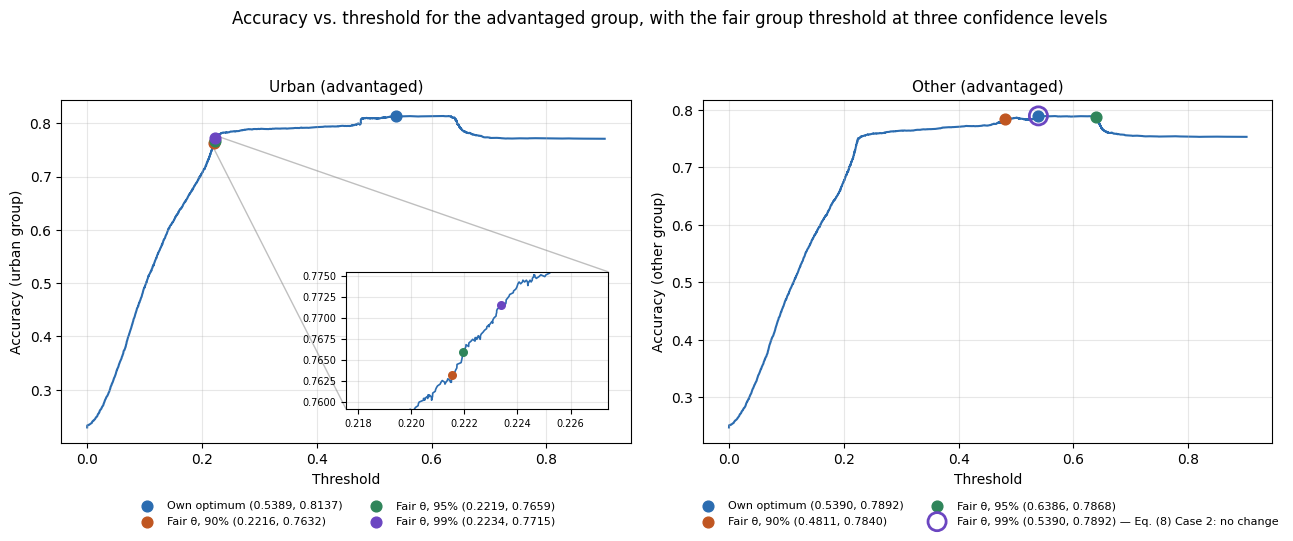

In [26]:
# ============================================================
# Accuracy vs threshold for the advantaged group in BOTH pairings,
# with the fair group threshold at all three confidence levels.
# One figure, two panels. Retrains nothing.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LEVELS = [("90%", 1.645, "#c05621"),
          ("95%", 1.960, "#2f855a"),
          ("99%", 2.576, "#6b46c1")]


def draw_panel(ax, adv, disadv):
    probs_adv = probs[group_mask[adv]]
    y_adv     = y_test[group_mask[adv]]
    theta_opt, a_opt, N_adv = group_data[adv]
    _,         a_dis, N_dis = group_data[disadv]

    taus = np.unique(probs_adv)
    accs = np.array([((probs_adv >= t).astype(int) == y_adv).mean() for t in taus])

    marks = []
    for cl_label, z_c, colour in LEVELS:
        target, _case = solve_target_accuracy(
            a_disadv=a_dis, N_disadv=N_dis,
            a_bar_adv=a_opt, N_adv=N_adv, z_alpha=z_c)
        if target is None:
            continue
        if abs(target - a_opt) < 1e-9:                       # Case 2
            marks.append((cl_label, theta_opt, a_opt, colour, True))
        else:
            th, ac, _ = find_constrained_threshold(
                probs_adv, y_adv, a_fixed=a_dis, N_fixed=N_dis, z_alpha=z_c)
            marks.append((cl_label, th, ac, colour, False))

    ax.plot(taus, accs, lw=1.5, color="#2b6cb0", zorder=1)
    ax.scatter([theta_opt], [a_opt], color="#2b6cb0", s=60, zorder=5,
               label=f"Own optimum ({theta_opt:.4f}, {a_opt:.4f})")

    for cl_label, th, ac, colour, is_case2 in marks:
        if is_case2:
            # Sits on top of the optimum -- draw as a ring so both show
            ax.scatter([th], [ac], facecolors="none", edgecolors=colour,
                       s=170, linewidths=2.0, zorder=6,
                       label=f"Fair θ, {cl_label} ({th:.4f}, {ac:.4f}) — Eq. (8) Case 2: no change")
        else:
            ax.scatter([th], [ac], color=colour, s=60, zorder=5,
                       label=f"Fair θ, {cl_label} ({th:.4f}, {ac:.4f})")

    # Inset zoom only when the markers bunch together
    ths = [m[1] for m in marks]
    acs = [m[2] for m in marks]
    if ths and (max(ths) - min(ths)) < 0.05 * (taus.max() - taus.min()):
        axin = ax.inset_axes([0.50, 0.10, 0.46, 0.40])
        axin.plot(taus, accs, lw=1.2, color="#2b6cb0")
        for _cl, th, ac, colour, _c2 in marks:
            axin.scatter([th], [ac], color=colour, s=30, zorder=5)
        axin.set_xlim(min(ths) - 0.004, max(ths) + 0.004)
        axin.set_ylim(min(acs) - 0.004, max(acs) + 0.004)
        axin.grid(alpha=0.3)
        axin.tick_params(labelsize=7)
        ax.indicate_inset_zoom(axin, edgecolor="gray")

    ax.set_xlabel("Threshold")
    ax.set_ylabel(f"Accuracy ({adv} group)")
    ax.set_title(f"{adv.capitalize()} (advantaged)", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14),
              ncol=2, fontsize=8, frameon=False)


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
draw_panel(axes[0], adv_ur, disadv_ur)
draw_panel(axes[1], adv_yo, disadv_yo)
fig.suptitle("Accuracy vs. threshold for the advantaged group, with the fair "
             "group threshold at three confidence levels", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("fig_thresholds_both_groups.png", dpi=150, bbox_inches="tight")
plt.show()